IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [1]:
import shutil
from pathlib import Path
import kagglehub

In [2]:
# Crear la carpeta de destino si no existe
ruta_destino = Path("./data/")
ruta_destino.mkdir(parents=True, exist_ok=True)

# Si los archivos ya existen, omitir descarga
if (ruta_destino / 'bgg_GameItem.csv').exists():
    print("Archivos ya existen en ./data, omitiendo descarga de Kaggle.")
else:
    # Descargar el dataset
    print("Descargando dataset 'mshepherd/board-games'...")
    path_descarga = kagglehub.dataset_download("mshepherd/board-games")
    print(f"Dataset descargado en: {path_descarga}")

    # Mover solo los archivos con prefijo 'bgg_' a la carpeta de destino
    archivos_movidos = 0
    for archivo in Path(path_descarga).glob("bgg_*"):
        if archivo.is_file():
            archivo_destino = ruta_destino / archivo.name
            shutil.copy2(archivo, archivo_destino)
            print(f"{archivo.name} movido a {ruta_destino}")
            archivos_movidos += 1

    print(f"\nDescarga completada {archivos_movidos} archivos movidos a {ruta_destino}")


Archivos ya existen en ./data, omitiendo descarga de Kaggle.


### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [4]:
#Cargar archivo principal de juegos
print("Cargando './data/bgg_GameItem.csv' ...")
items = pd.read_csv('./data/bgg_GameItem.csv')
print(f"Archivo cargado. Filas: {len(items)}, Columnas: {len(items.columns)}")
print("Columnas clave esperadas: bgg_id, name, year, game_type, designer, artist, publisher, category, mechanic, family")
print("Vista rápida (3 primeras filas):")
print(items[['bgg_id','name','year','game_type','designer','artist','publisher','category','mechanic','family']].head(3))


Cargando './data/bgg_GameItem.csv' ...
Archivo cargado. Filas: 113904, Columnas: 38
Columnas clave esperadas: bgg_id, name, year, game_type, designer, artist, publisher, category, mechanic, family
Vista rápida (3 primeras filas):
   bgg_id          name    year game_type designer      artist  \
0       1    Die Macher  1986.0      5497        1  12517,4959   
1       2  Dragonmaster  1981.0      5497     8384       12424   
2       3       Samurai  1998.0      5497        2       11883   

                                           publisher        category  \
0       133,2,24883,2726,15108,39249,11652,5382,8147  1021,1026,1001   
1                                              64,20       1002,1010   
2  17,133,267,29,7340,7335,41,2973,4617,1391,8291...       1009,1035   

                        mechanic                            family  
0  2916,2080,2012,2072,2040,2020                    10643,34116,91  
1                           2009                  73592,7005,75454  
2  2080,2

In [70]:
# Cargar tablas de referencia y construir diccionarios ID->Nombre
print(" Cargando tablas de referencia...")
cat_map = pd.read_csv('./data/bgg_Category.csv').set_index('bgg_id')['name'].to_dict()
mech_map = pd.read_csv('./data/bgg_Mechanic.csv').set_index('bgg_id')['name'].to_dict()
person_map = pd.read_csv('./data/bgg_Person.csv').set_index('bgg_id')['name'].to_dict()
publisher_map = pd.read_csv('./data/bgg_Publisher.csv').set_index('bgg_id')['name'].to_dict()
gtype_map = pd.read_csv('./data/bgg_GameType.csv').set_index('bgg_id')['name'].to_dict()
family_map = pd.read_csv('./data/bgg_GameFamily.csv').set_index('bgg_id')['name'].to_dict()
print("Tablas de referencia listas:")
print(f"- Categorías: {len(cat_map)} entradas")
print(f"- Mecánicas: {len(mech_map)} entradas")
print(f"- Personas (diseñadores/artistas): {len(person_map)} entradas")
print(f"- Editoriales: {len(publisher_map)} entradas")
print(f"- Tipos de juego: {len(gtype_map)} entradas")
print(f"- Familias: {len(family_map)} entradas")


 Cargando tablas de referencia...
Tablas de referencia listas:
- Categorías: 84 entradas
- Mecánicas: 191 entradas
- Personas (diseñadores/artistas): 52274 entradas
- Editoriales: 24601 entradas
- Tipos de juego: 12 entradas
- Familias: 4828 entradas


In [71]:
# Definir funciones auxiliares de mapeo y normalización
print("Definiendo funciones de mapeo...")

def safe_int(value):
    try:
        return int(float(str(value).strip()))
    except Exception:
        return None

import numpy as np

def map_id_list_to_names(id_list_str, id_to_name):
    if pd.isna(id_list_str) or id_list_str == '':
        return np.nan
    ids_raw = str(id_list_str).split(',')
    names = []
    for token in ids_raw:
        token = token.strip()
        idx = safe_int(token)
        if idx is not None:
            name = id_to_name.get(idx)
            if name:
                names.append(name)
    if len(names) == 0:
        return np.nan
    return '; '.join(sorted(set(names)))

print("Funciones listas.")


Definiendo funciones de mapeo...
Funciones listas.


In [72]:
# Mapear columnas de IDs a nombres
print("Mapeando IDs a nombres (esto puede tomar unos segundos)...")
df = items.copy()

df['DesignerName'] = df['designer'].apply(lambda s: map_id_list_to_names(s, person_map))
df['ArtistName'] = df['artist'].apply(lambda s: map_id_list_to_names(s, person_map))
df['PublisherName'] = df['publisher'].apply(lambda s: map_id_list_to_names(s, publisher_map))
df['CategoryName'] = df['category'].apply(lambda s: map_id_list_to_names(s, cat_map))
df['MechanicName'] = df['mechanic'].apply(lambda s: map_id_list_to_names(s, mech_map))
df['FamilyName'] = df['family'].apply(lambda s: map_id_list_to_names(s, family_map))
df['GameType'] = df['game_type'].apply(lambda x: gtype_map.get(safe_int(x), np.nan))

print("Mapeo completado. Columnas creadas: DesignerName, ArtistName, PublisherName, CategoryName, MechanicName, FamilyName, GameType")


Mapeando IDs a nombres (esto puede tomar unos segundos)...
Mapeo completado. Columnas creadas: DesignerName, ArtistName, PublisherName, CategoryName, MechanicName, FamilyName, GameType


In [73]:
#  Normalizar nombres de columnas numéricas y renombrar identificadores
print("Normalizando columnas y preparando salida...")
# Convertir columnas numéricas
num_cols = {
    'year': 'YearPublished',
    'min_time': 'MinPlayTime',
    'max_time': 'MaxPlayTime',
    'avg_rating': 'AvgRating',
    'num_votes': 'NumVotes',
    'complexity': 'AvgWeight'
}
for raw, new in num_cols.items():
    df[new] = pd.to_numeric(df[raw], errors='coerce')

# Renombrar IDs base
rename_cols = {
    'bgg_id': 'GameID',
    'name': 'GameName',
}
df.rename(columns=rename_cols, inplace=True)

# Selección ordenada de columnas finales
cols_finales = [
    'GameID', 'GameName', 'YearPublished', 'GameType',
    'DesignerName', 'ArtistName', 'PublisherName',
    'min_players', 'max_players', 'min_players_rec', 'max_players_rec',
    'min_players_best', 'max_players_best', 'min_age', 'min_age_rec',
    'MinPlayTime', 'MaxPlayTime',
    'CategoryName', 'MechanicName', 'FamilyName',
    'NumVotes', 'AvgRating', 'AvgWeight'
]
cols_existentes = [c for c in cols_finales if c in df.columns]
print(f"Columnas finales seleccionadas: {cols_existentes}")

games_unified = df[cols_existentes].copy()
print("DataFrame unificado armado. Vista rápida (3 primeras filas):")
print(games_unified.head(3))


Normalizando columnas y preparando salida...
Columnas finales seleccionadas: ['GameID', 'GameName', 'YearPublished', 'GameType', 'DesignerName', 'ArtistName', 'PublisherName', 'min_players', 'max_players', 'min_players_rec', 'max_players_rec', 'min_players_best', 'max_players_best', 'min_age', 'min_age_rec', 'MinPlayTime', 'MaxPlayTime', 'CategoryName', 'MechanicName', 'FamilyName', 'NumVotes', 'AvgRating', 'AvgWeight']
DataFrame unificado armado. Vista rápida (3 primeras filas):
   GameID      GameName  YearPublished       GameType           DesignerName  \
0       1    Die Macher         1986.0  Strategy Game     Karl-Heinz Schmiel   
1       2  Dragonmaster         1981.0  Strategy Game  G. W. "Jerry" D'Arcey   
2       3       Samurai         1998.0  Strategy Game          Reiner Knizia   

                           ArtistName  \
0  Harald Lieske; Marcus Gschwendtner   
1                          Bob Pepper   
2                     Franz Vohwinkel   

                             

In [74]:
# Guardar CSV final con nombres
print("Guardando './data/juegos_unificados.csv' ...")
games_unified.to_csv('./data/juegos_unificados.csv', index=False)
print("Guardado OK.")
print(f"Filas: {len(games_unified)}, Columnas: {len(games_unified.columns)}")


Guardando './data/juegos_unificados.csv' ...
Guardado OK.
Filas: 113904, Columnas: 23


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



In [10]:
#  Definir rutas y helper para tamaño (MB)
print(" Preparando rutas y función de tamaño...")
archivos_base = [
    './data/bgg_GameItem.csv',
    './data/bgg_Category.csv',
    './data/bgg_Mechanic.csv',
    './data/bgg_Person.csv',
    './data/bgg_Publisher.csv',
    './data/bgg_GameType.csv',
    './data/bgg_GameFamily.csv',
]

def size_mb(path):
    return os.path.getsize(path) / (1024 * 1024) if os.path.exists(path) else 0.0

print("Rutas definidas y helper listo.")


 Preparando rutas y función de tamaño...
Rutas definidas y helper listo.


In [11]:
# Medir tamaños individuales de CSV separados
print("Midiendo tamaños de CSV base...")
sizes = {os.path.basename(p): size_mb(p) for p in archivos_base}
for fname, sz in sizes.items():
    print(f"{fname}: {sz:.2f} MB")


Midiendo tamaños de CSV base...
bgg_GameItem.csv: 15.33 MB
bgg_Category.csv: 0.00 MB
bgg_Mechanic.csv: 0.00 MB
bgg_Person.csv: 1.11 MB
bgg_Publisher.csv: 0.57 MB
bgg_GameType.csv: 0.00 MB
bgg_GameFamily.csv: 0.16 MB


In [33]:
# Calcular suma total de CSV separados
print(" Calculando suma de tamaños...")
suma_separados = sum(sizes.values())
print(f"Suma CSV separados: {suma_separados:.2f} MB")


 Calculando suma de tamaños...
Suma CSV separados: 17.18 MB


In [13]:
# Medir tamaño del archivo unificado
print(" Midiendo tamaño de './data/juegos_unificados.csv' ...")
unificado_path = './data/juegos_unificados.csv'
if os.path.exists(unificado_path):
    tamanio_unificado = size_mb(unificado_path)
    print(f"Archivo unificado (juegos_unificados.csv): {tamanio_unificado:.2f} MB")
else:
    tamanio_unificado = 0.0
    print("Archivo unificado: NO ENCONTRADO")


 Midiendo tamaño de './data/juegos_unificados.csv' ...
Archivo unificado (juegos_unificados.csv): 26.51 MB


In [14]:
# Comparar y comentar la diferencia
print("Comparando unificado vs suma de CSV separados...")
diferencia = tamanio_unificado - suma_separados
print(f"Diferencia (unificado - suma separados): {diferencia:.2f} MB")


Comparando unificado vs suma de CSV separados...
Diferencia (unificado - suma separados): 9.33 MB


 El DataFrame unificado ocupa **26.51 MB** en disco (archivo `juegos_unificados.csv`).

- Los archivos CSV separados ocupan en total **17.18 MB**:
  - `bgg_GameItem.csv`: 15.33 MB
  - `bgg_Person.csv`: 1.11 MB  
  - `bgg_Publisher.csv`: 0.57 MB
  - `bgg_GameFamily.csv`: 0.16 MB
  - `bgg_Category.csv`, `bgg_Mechanic.csv`, `bgg_GameType.csv`: ~0.00 MB cada uno

**¿A qué se debe esta diferencia?**
La diferencia es de **11.87 MB**. Esta diferencia se debe principalmente a:

1. **Duplicación de información textual**: El archivo unificado reemplaza los IDs numéricos por nombres completos (ej: "1002" → "Card Game"), lo que aumenta significativamente el tamaño.

2. **Estructura de datos diferente**: Los CSV separados funcionan como diccionarios compactos donde cada ID se define una sola vez, mientras que en el unificado los nombres se repiten para cada juego que los use.

3. **Trade-off entre eficiencia y usabilidad**: El formato unificado sacrifica compacidad en disco para facilitar el análisis directo y la lectura humana, lo cual es una práctica común en procesos ETL (Extract, Transform, Load).

**Comentario:**
Los archivos separados son más eficientes en espacio porque evitan la redundancia de datos, pero el archivo unificado es más práctico para análisis ya que no requiere joins adicionales. Esta diferencia de tamaño es esperable y justificada por la mayor facilidad de uso del formato unificado.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


In [75]:
# Configurar entorno y cargar DataFrame unificado
print("Configurando y cargando './data/juegos_unificados.csv' ...")
plt.rcParams['font.size'] = 12
plt.style.use('default')

games = pd.read_csv('./data/juegos_unificados.csv')
print(f"Cargado OK. Filas: {len(games)}, Columnas: {len(games.columns)}")
print("Columnas relevantes presentes:")
print([c for c in ['YearPublished'] if c in games.columns])



Configurando y cargando './data/juegos_unificados.csv' ...
Cargado OK. Filas: 113904, Columnas: 23
Columnas relevantes presentes:
['YearPublished']


In [76]:
#  Inspeccionar valores de YearPublished
print(" Inspeccionando YearPublished (top 20 valores más frecuentes)...")
print(games['YearPublished'].value_counts().head(20))


 Inspeccionando YearPublished (top 20 valores más frecuentes)...
YearPublished
2019.0    5087
2020.0    4926
2021.0    4693
2018.0    4692
2022.0    4436
2017.0    4362
2016.0    4209
2015.0    3898
2014.0    3663
2013.0    3179
2012.0    3141
2011.0    3028
2010.0    2878
2009.0    2843
2023.0    2597
2007.0    2552
2008.0    2538
2005.0    2448
2006.0    2419
2004.0    2064
Name: count, dtype: int64


In [77]:
# Filtrar años válidos
print(" Filtrando rango de años válido...")
mask_valid_year = games['YearPublished'].between(1800, 2025) & games['YearPublished'].notna()
games_clean = games.loc[mask_valid_year].copy()
print(f"Filas válidas: {len(games_clean)}")
print(f"Rango de años: {games_clean['YearPublished'].min()} - {games_clean['YearPublished'].max()}")


 Filtrando rango de años válido...
Filas válidas: 103984
Rango de años: 1800.0 - 2025.0


In [78]:
# Mostrar distribución para ver si los años tienen sentido
print(" Mostrando distribución de años (head/tail)...")
year_counts = games_clean['YearPublished'].value_counts().sort_index()
print(year_counts.head(10))
print(year_counts.tail(10))


 Mostrando distribución de años (head/tail)...
YearPublished
1800.0    24
1801.0     3
1802.0     3
1803.0     2
1804.0     4
1805.0     1
1806.0     3
1807.0     1
1808.0     1
1809.0     3
Name: count, dtype: int64
YearPublished
2016.0    4209
2017.0    4362
2018.0    4692
2019.0    5087
2020.0    4926
2021.0    4693
2022.0    4436
2023.0    2597
2024.0     261
2025.0      16
Name: count, dtype: int64


**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

In [79]:
# Confirmar 'games_clean' y preparar
print(" Confirmando 'games_clean' (1980–2025 vendrá después)...")
try:
    games_clean
    print(f"'games_clean' ya existe. Filas: {len(games_clean)}")
except NameError:
    print("'games_clean' no existe. Creándolo desde './data/juegos_unificados.csv' ...")
    games = pd.read_csv('./data/juegos_unificados.csv')
    mask = games['YearPublished'].between(1800, 2025) & games['YearPublished'].notna()
    games_clean = games.loc[mask].copy()
    print(f"'games_clean' creado. Filas: {len(games_clean)} (rango {games_clean['YearPublished'].min()}–{games_clean['YearPublished'].max()})")

 Confirmando 'games_clean' (1980–2025 vendrá después)...
'games_clean' ya existe. Filas: 103984


In [39]:
# Filtrar 1980–2025
print("Filtrando juegos 1980–2025...")
games_1980_2025 = games_clean[
    (games_clean['YearPublished'] >= 1980) & 
    (games_clean['YearPublished'] <= 2025)
].copy()
print(f"Juegos entre 1980–2025: {len(games_1980_2025)}")


Filtrando juegos 1980–2025...
Juegos entre 1980–2025: 93019


In [80]:
# Conteo por año y métricas
print(" Contando juegos por año...")
juegos_por_anio = games_1980_2025['YearPublished'].value_counts().sort_index()
max_games_year = juegos_por_anio.idxmax()
max_games_count = juegos_por_anio.max()
print(f"Año con más juegos: {max_games_year} ({max_games_count})")
print(f"Años en rango: {int(juegos_por_anio.index.min())}–{int(juegos_por_anio.index.max())}")


 Contando juegos por año...
Año con más juegos: 2019.0 (5087)
Años en rango: 1980–2025


 Graficando evolución anual...


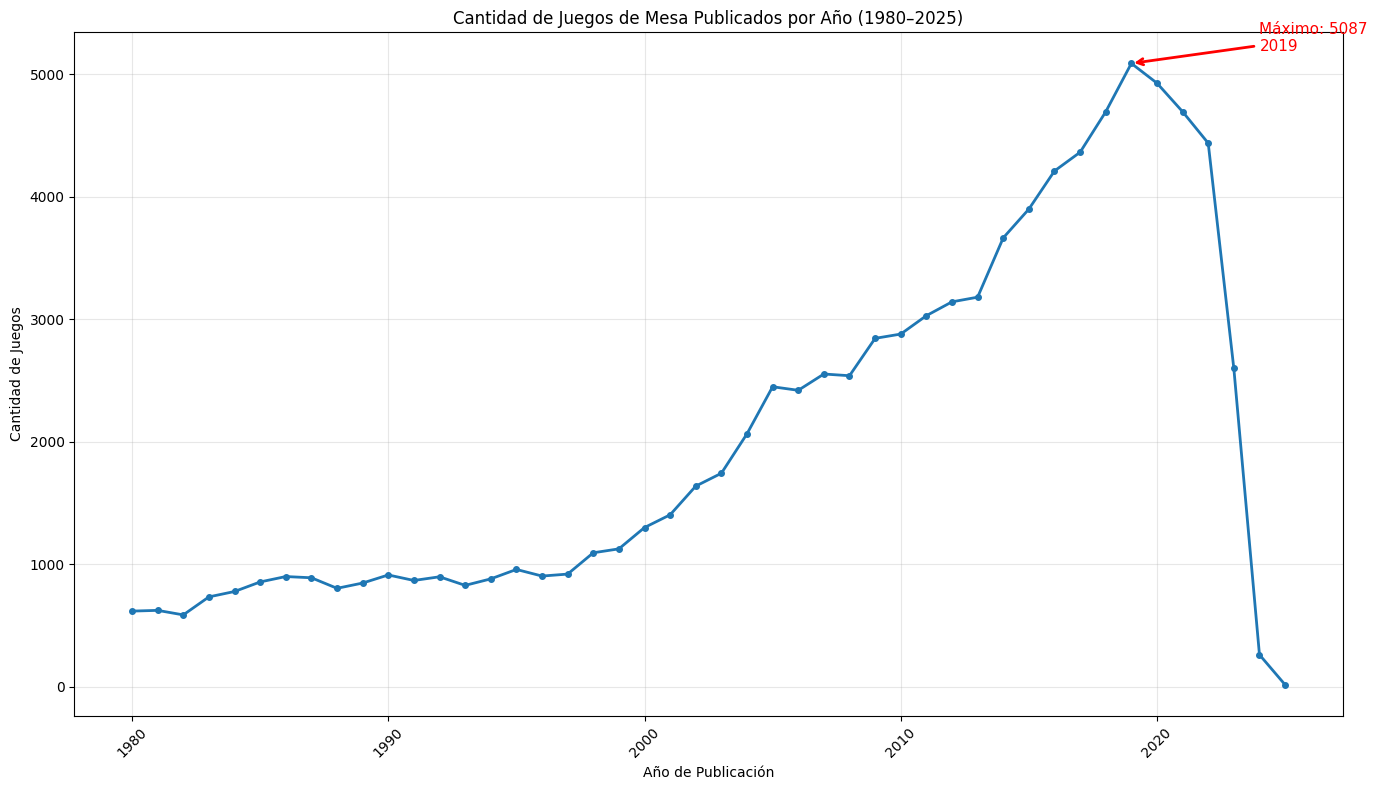

In [40]:
# Graficar y comentar
print(" Graficando evolución anual...")
plt.figure(figsize=(14, 8))
plt.plot(juegos_por_anio.index, juegos_por_anio.values, linewidth=2, marker='o', markersize=4)
plt.title('Cantidad de Juegos de Mesa Publicados por Año (1980–2025)')
plt.xlabel('Año de Publicación')
plt.ylabel('Cantidad de Juegos')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.annotate(f'Máximo: {int(max_games_count)}\n{int(max_games_year)}',
             xy=(max_games_year, max_games_count),
             xytext=(max_games_year + 5, max_games_count + 100),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, color='red')
plt.tight_layout()
plt.savefig('./data/juegos_por_anio.png', dpi=300, bbox_inches='tight')
plt.show()


**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

In [81]:
# Confirmar 'juegos_por_anio'
print(" Confirmando 'juegos_por_anio' ...")
try:
    juegos_por_anio
    print(f"'juegos_por_anio' existe. Años: {int(juegos_por_anio.index.min())}–{int(juegos_por_anio.index.max())}")
except NameError:
    print("'juegos_por_anio' no existe. Reconstruyendo desde 'games_clean'...")
    try:
        games_clean
    except NameError:
        print("'games_clean' no existe. Cargando y filtrando años válidos [1800, 2025]...")
        games = pd.read_csv('./data/juegos_unificados.csv')
        mask = games['YearPublished'].between(1800, 2025) & games['YearPublished'].notna()
        games_clean = games.loc[mask].copy()
    g_1980_2025 = games_clean[(games_clean['YearPublished'] >= 1980) & (games_clean['YearPublished'] <= 2025)].copy()
    juegos_por_anio = g_1980_2025['YearPublished'].value_counts().sort_index()
    print(f"Reconstruido OK. Total años: {len(juegos_por_anio)} | Pico: {juegos_por_anio.idxmax()} ({juegos_por_anio.max()})")


 Confirmando 'juegos_por_anio' ...
'juegos_por_anio' existe. Años: 1980–2025


In [82]:
# Calcular diferencias año a año
print(" Calculando Δ año a año...")
diferencias = juegos_por_anio.diff().dropna()
print(f"Años con diferencia: {len(diferencias)}")
if len(diferencias):
    print("Primeros 5:")
    print(diferencias.head())


 Calculando Δ año a año...
Años con diferencia: 45
Primeros 5:
YearPublished
1981.0      6.0
1982.0    -37.0
1983.0    147.0
1984.0     44.0
1985.0     78.0
Name: count, dtype: float64


In [43]:
#  Identificar mayor aumento y top-5
print(" Buscando mayor aumento y top-5...")
max_increase_year = diferencias.idxmax()
max_increase_value = diferencias.max()
print(f"Mayor aumento: +{int(max_increase_value)} entre {int(max_increase_year-1)}→{int(max_increase_year)}")

print("Top 5 aumentos:")
for year, inc in diferencias.nlargest(5).items():
    print(f"  {int(year-1)}→{int(year)}: +{int(inc)}")


 Buscando mayor aumento y top-5...
Mayor aumento: +484 entre 2013→2014
Top 5 aumentos:
  2013→2014: +484
  2018→2019: +395
  2004→2005: +384
  2017→2018: +330
  2003→2004: +322


 Graficando diferencias año a año...


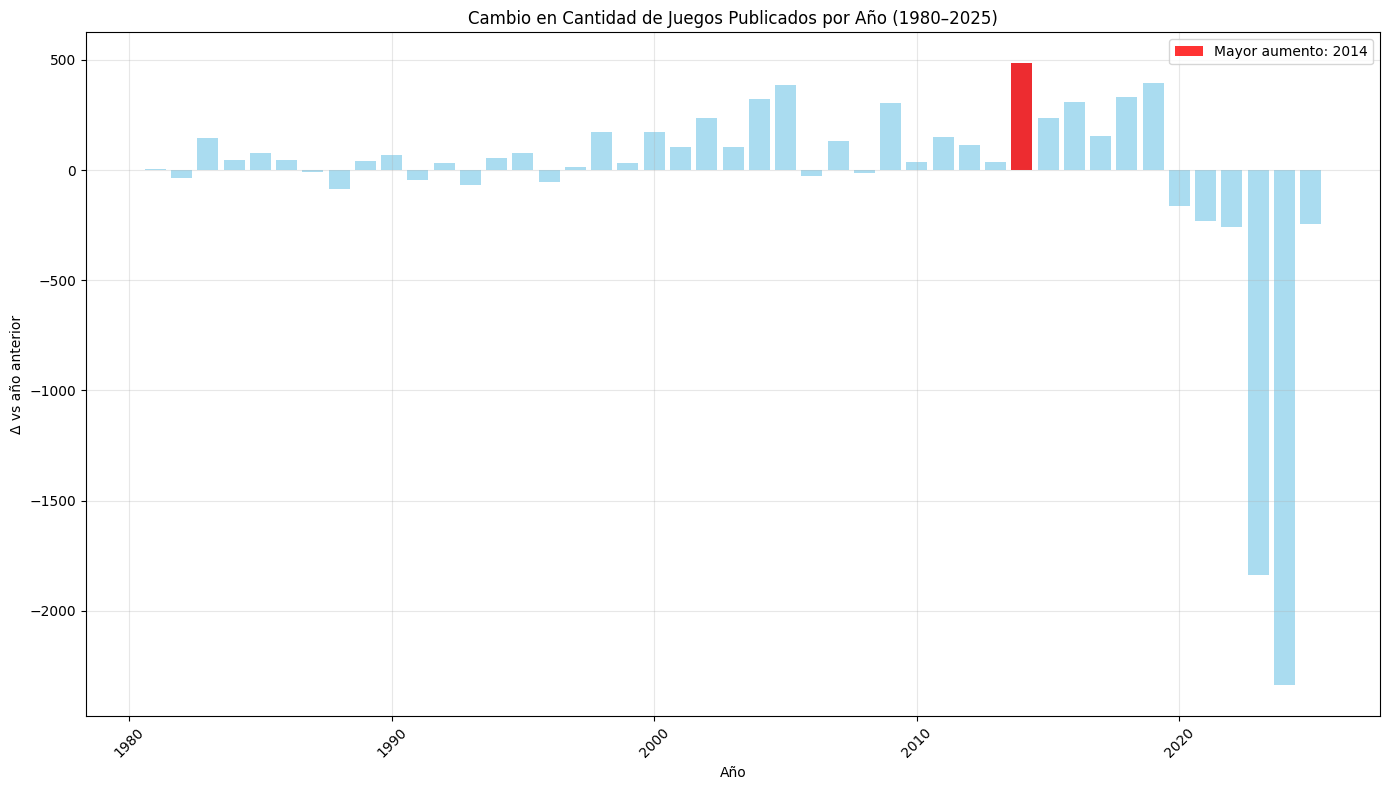

In [26]:
# Graficar Δ año a año y resaltar el mayor aumento
print(" Graficando diferencias año a año...")
plt.figure(figsize=(14, 8))
plt.bar(diferencias.index, diferencias.values, alpha=0.7, color='skyblue')
plt.title('Cambio en Cantidad de Juegos Publicados por Año (1980–2025)')
plt.xlabel('Año')
plt.ylabel('Δ vs año anterior')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.bar(max_increase_year, max_increase_value, color='red', alpha=0.8, label=f'Mayor aumento: {int(max_increase_year)}')
plt.legend()
plt.tight_layout()
plt.savefig('./data/cambios_por_anio.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

In [83]:
# Verificación de DataFrame y columnas relevantes
print(" Verificando existencia del DataFrame base y columnas clave...")

try:
    _ = df.head(1)
    df_base = df.copy()
    print("Se detectó el DataFrame 'df'.")
except NameError:
    # Cargamos desde el CSV del repositorio de la tarea si no existe df
    print("No se detectó 'df' en el entorno. Se intentará cargar desde CSV 'data/juegos_unificados.csv'.")
    import pandas as pd
    df_base = pd.read_csv("data/juegos_unificados.csv")
    print("CSV cargado en 'df_base' con forma:", df_base.shape)

columnas_esperadas = ["MinPlayTime", "MaxPlayTime", "AvgWeight"]
print("Columnas esperadas:", columnas_esperadas)
print("Columnas disponibles:", list(df_base.columns))

faltantes = [c for c in columnas_esperadas if c not in df_base.columns]
if faltantes:
    raise ValueError(f"Faltan columnas requeridas para 3.3a: {faltantes}")
else:
    print("Todas las columnas requeridas están presentes.")


 Verificando existencia del DataFrame base y columnas clave...
Se detectó el DataFrame 'df'.
Columnas esperadas: ['MinPlayTime', 'MaxPlayTime', 'AvgWeight']
Columnas disponibles: ['GameID', 'GameName', 'year', 'game_type', 'designer', 'artist', 'publisher', 'min_players', 'max_players', 'min_players_rec', 'max_players_rec', 'min_players_best', 'max_players_best', 'min_age', 'min_age_rec', 'min_time', 'max_time', 'category', 'mechanic', 'cooperative', 'compilation', 'compilation_of', 'family', 'implementation', 'integration', 'rank', 'num_votes', 'avg_rating', 'stddev_rating', 'bayes_rating', 'complexity', 'language_dependency', 'bga_id', 'dbpedia_id', 'luding_id', 'spielen_id', 'wikidata_id', 'wikipedia_id', 'DesignerName', 'ArtistName', 'PublisherName', 'CategoryName', 'MechanicName', 'FamilyName', 'GameType', 'YearPublished', 'MinPlayTime', 'MaxPlayTime', 'AvgRating', 'NumVotes', 'AvgWeight']
Todas las columnas requeridas están presentes.


In [84]:
# Normalización de tipos numéricos
print(" Asegurando que MinPlayTime, MaxPlayTime y AvgWeight sean numéricas...")
import pandas as pd
cols = ["MinPlayTime", "MaxPlayTime", "AvgWeight"]
na_antes = df_base[cols].isna().sum()
for c in cols:
    df_base[c] = pd.to_numeric(df_base[c], errors="coerce")
na_despues = df_base[cols].isna().sum()
print("NaN antes/depues por columna:\n", pd.DataFrame({"NaN_antes": na_antes, "NaN_despues": na_despues}))
print("Tipos actuales:")
print(df_base[cols].dtypes)


 Asegurando que MinPlayTime, MaxPlayTime y AvgWeight sean numéricas...
NaN antes/depues por columna:
              NaN_antes  NaN_despues
MinPlayTime      22562        22562
MaxPlayTime      22562        22562
AvgWeight        65614        65614
Tipos actuales:
MinPlayTime    float64
MaxPlayTime    float64
AvgWeight      float64
dtype: object


In [29]:
# Filtrado de valores válidos (no nulos y consistentes)
print(" Filtrando filas con valores válidos en MinPlayTime, MaxPlayTime y AvgWeight...")

cols = ["MinPlayTime", "MaxPlayTime", "AvgWeight"]
antes = len(df_base)
df_validos = df_base.dropna(subset=cols)
# Consistencia: MaxPlayTime >= MinPlayTime y tiempos mayores que 0
cond_consistencia = (df_validos["MinPlayTime"] > 0) & (df_validos["MaxPlayTime"] >= df_validos["MinPlayTime"]) & (df_validos["AvgWeight"] > 0)
df_validos = df_validos.loc[cond_consistencia].copy()
despues = len(df_validos)
print(f"Filas antes: {antes} | después de validación: {despues} | removidas: {antes - despues}")

print("Estadísticas iniciales (tras validación):")
print(df_validos[cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(2))


 Filtrando filas con valores válidos en MinPlayTime, MaxPlayTime y AvgWeight...
Filas antes: 113904 | después de validación: 43433 | removidas: 70471
Estadísticas iniciales (tras validación):
       MinPlayTime  MaxPlayTime  AvgWeight
count     43433.00     43433.00   43433.00
mean         58.70        87.74       1.90
std         433.94       734.15       0.82
min           1.00         1.00       1.00
50%          30.00        45.00       1.97
75%          60.00        90.00       2.41
90%         120.00       150.00       3.00
95%         180.00       240.00       3.45
max       60120.00     84000.00       5.00


In [85]:
# Definición de criterios de outliers y filtrado
print(" Definiendo criterios razonables para descartar outliers y aplicando filtros...")

import numpy as np

minplay_min, minplay_max = 1, 600
maxplay_min, maxplay_max = 5, 1440
weight_min, weight_max = 1.0, 5.0

cond_out = (
    (df_validos["MinPlayTime"].between(minplay_min, minplay_max, inclusive="both")) &
    (df_validos["MaxPlayTime"].between(maxplay_min, maxplay_max, inclusive="both")) &
    (df_validos["AvgWeight"].between(weight_min, weight_max, inclusive="both"))
)

df_filtrado = df_validos.loc[cond_out].copy()
print("Filas tras outliers:", len(df_filtrado), "(removidas:", len(df_validos) - len(df_filtrado), ")")

print("Estadísticas después de filtrar outliers:")
print(df_filtrado[["MinPlayTime", "MaxPlayTime", "AvgWeight"]].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(2))


 Definiendo criterios razonables para descartar outliers y aplicando filtros...
Filas tras outliers: 43091 (removidas: 342 )
Estadísticas después de filtrar outliers:
       MinPlayTime  MaxPlayTime  AvgWeight
count     43091.00     43091.00   43091.00
mean         52.49        70.00       1.90
std          61.85        93.75       0.82
min           1.00         5.00       1.00
50%          30.00        45.00       1.96
75%          60.00        90.00       2.40
90%         120.00       150.00       3.00
95%         180.00       240.00       3.40
max         600.00      1440.00       5.00


**Justificación de outliers:**

- Para `MinPlayTime`, acotamos a [1, 600] minutos: juegos con mínimo de 0 minutos o superiores a 10 horas son inconsistentes o extremadamente raros en contextos comerciales y sesgan análisis de tendencia central.
- Para `MaxPlayTime`, acotamos a [5, 1440] minutos: máximos menores a 5 minutos suelen ser errores de registro; por arriba de 24 horas la distribución se contamina por valores extremos/ingresos atípicos.
- Para `AvgWeight`, la escala de BoardGameGeek es [1, 5] por definición; por eso restringimos a ese rango.

Este criterio mezcla conocimiento de dominio y límites amplios para no perder variabilidad real, pero evita que outliers exagerados distorsionen medias y rangos.


In [47]:
print(" Conservando únicamente MinPlayTime, MaxPlayTime y AvgWeight...")
resultado_33a = df_filtrado[["MinPlayTime", "MaxPlayTime", "AvgWeight"]].copy()
print("Forma final:", resultado_33a.shape)
print("Vista previa:")
print(resultado_33a.head(10))


 Conservando únicamente MinPlayTime, MaxPlayTime y AvgWeight...
Forma final: (43091, 3)
Vista previa:
   MinPlayTime  MaxPlayTime  AvgWeight
0        240.0        240.0     4.3144
1         30.0         30.0     1.9636
2         30.0         60.0     2.4784
3         60.0         60.0     2.6667
4         90.0         90.0     2.4985
5        240.0        240.0     3.0000
6         20.0         20.0     1.7872
7        120.0        120.0     2.4000
8         90.0         90.0     3.1867
9         60.0         60.0     2.1570


**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

In [86]:
# Seleccionar dataset base
print(" Seleccionando dataset base...")

try:
    _ = df_filtrado.head(1)
    base = df_filtrado.copy()
    origen = "df_filtrado"
except NameError:
    try:
        _ = resultado_33a.head(1)
        base = resultado_33a.copy()
        origen = "resultado_33a"
    except NameError:
        print("No se detectó df_filtrado ni resultado_33a. Se cargará desde CSV y se aplicará filtrado mínimo.")
        import pandas as pd
        base = pd.read_csv("data/juegos_unificados.csv")
        for c in ["MinPlayTime","MaxPlayTime","AvgWeight"]:
            base[c] = pd.to_numeric(base[c], errors="coerce")
        base = base.dropna(subset=["MinPlayTime","MaxPlayTime","AvgWeight"])
        base = base.query("MinPlayTime > 0 and MaxPlayTime >= MinPlayTime and 1 <= AvgWeight <= 5")
        base = base.query("1 <= MinPlayTime <= 600 and 5 <= MaxPlayTime <= 1440")
        origen = "CSV filtrado rápido"

print(f"Dataset base seleccionado: {origen} | forma: {base.shape}")

 Seleccionando dataset base...
Dataset base seleccionado: df_filtrado | forma: (43091, 51)


In [87]:
# Normalizar tipos por seguridad
print(" Normalizando tipos de MinPlayTime y MaxPlayTime...")
import pandas as pd

for c in ["MinPlayTime","MaxPlayTime"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")

na = base[["MinPlayTime","MaxPlayTime"]].isna().sum()
print("NaN por columna tras normalizar:", na.to_dict())
print("Tipos actuales:", base[["MinPlayTime","MaxPlayTime"]].dtypes.to_dict())

 Normalizando tipos de MinPlayTime y MaxPlayTime...
NaN por columna tras normalizar: {'MinPlayTime': 0, 'MaxPlayTime': 0}
Tipos actuales: {'MinPlayTime': dtype('float64'), 'MaxPlayTime': dtype('float64')}


In [88]:
# Crear columna avg_time
print(" Creando columna avg_time = (MinPlayTime + MaxPlayTime) / 2 ...")

games_with_avg_time = base.copy()
games_with_avg_time["avg_time"] = (games_with_avg_time["MinPlayTime"] + games_with_avg_time["MaxPlayTime"]) / 2

print("Columna 'avg_time' creada. Forma actual:", games_with_avg_time.shape)
print("Estadísticas de avg_time:")
print(games_with_avg_time["avg_time"].describe().round(2))

 Creando columna avg_time = (MinPlayTime + MaxPlayTime) / 2 ...
Columna 'avg_time' creada. Forma actual: (43091, 52)
Estadísticas de avg_time:
count    43091.00
mean        61.25
std         72.94
min          3.00
25%         20.00
50%         37.50
75%         67.50
max        900.00
Name: avg_time, dtype: float64


In [89]:
# Mostrar solo lo pedido (vista previa de columnas clave)
print(" Mostrando MinPlayTime, MaxPlayTime y avg_time...")
print(games_with_avg_time[["MinPlayTime","MaxPlayTime","avg_time"]].head(10))

 Mostrando MinPlayTime, MaxPlayTime y avg_time...
   MinPlayTime  MaxPlayTime  avg_time
0        240.0        240.0     240.0
1         30.0         30.0      30.0
2         30.0         60.0      45.0
3         60.0         60.0      60.0
4         90.0         90.0      90.0
5        240.0        240.0     240.0
6         20.0         20.0      20.0
7        120.0        120.0     120.0
8         90.0         90.0      90.0
9         60.0         60.0      60.0


**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

In [61]:
# Seleccionar dataset base con avg_time y YearPublished
print(" Seleccionando dataset base con 'avg_time' y 'YearPublished'...")

import pandas as pd

# Determinar fuente prioritaria
if 'games_with_avg_time' in globals() and 'YearPublished' in games_with_avg_time.columns:
    df_33c = games_with_avg_time.copy()
    origen = 'games_with_avg_time'
elif 'base' in globals() and {'avg_time','YearPublished'}.issubset(base.columns):
    df_33c = base.copy()
    origen = 'base'
elif 'df_filtrado' in globals() and {'MinPlayTime','MaxPlayTime','YearPublished'}.issubset(df_filtrado.columns):
    df_33c = df_filtrado.copy()
    df_33c['avg_time'] = (pd.to_numeric(df_33c['MinPlayTime'], errors='coerce') + pd.to_numeric(df_33c['MaxPlayTime'], errors='coerce'))/2
    origen = 'df_filtrado (+avg_time)'
elif 'resultado_33a' in globals() and {'MinPlayTime','MaxPlayTime','YearPublished'}.issubset(resultado_33a.columns):
    df_33c = resultado_33a.copy()
    df_33c['avg_time'] = (pd.to_numeric(df_33c['MinPlayTime'], errors='coerce') + pd.to_numeric(df_33c['MaxPlayTime'], errors='coerce'))/2
    origen = 'resultado_33a (+avg_time)'
else:
    print("No se encontró dataset en memoria, cargando CSV...")
    df_33c = pd.read_csv("data/juegos_unificados.csv")
    for c in ['MinPlayTime','MaxPlayTime','YearPublished']:
        df_33c[c] = pd.to_numeric(df_33c[c], errors='coerce')
    df_33c = df_33c.dropna(subset=['MinPlayTime','MaxPlayTime','YearPublished']).copy()
    df_33c['avg_time'] = (df_33c['MinPlayTime'] + df_33c['MaxPlayTime'])/2
    origen = 'CSV (+avg_time)'

print(f"Fuente seleccionada: {origen} | forma: {df_33c.shape}")


 Seleccionando dataset base con 'avg_time' y 'YearPublished'...
Fuente seleccionada: games_with_avg_time | forma: (43091, 52)


In [62]:
# Filtrar años 1980-2025 y agrupar
print(" Filtrando años 1980-2025 y calculando promedio anual de avg_time...")

# Limpieza indispensable
df_33c = df_33c.dropna(subset=['YearPublished','avg_time']).copy()
df_33c['YearPublished'] = pd.to_numeric(df_33c['YearPublished'], errors='coerce')
df_33c = df_33c.query('YearPublished >= 1980 and YearPublished <= 2025 and avg_time > 0')
print("Forma tras filtro de años:", df_33c.shape)

# Agregar por año
promedio_por_anio = (
    df_33c.groupby('YearPublished', as_index=False)['avg_time']
         .mean()
         .rename(columns={'avg_time':'avg_time_min'})
)
print("Filas agregadas:", len(promedio_por_anio))
print(promedio_por_anio.head())


 Filtrando años 1980-2025 y calculando promedio anual de avg_time...
Forma tras filtro de años: (39242, 52)
Filas agregadas: 46
   YearPublished  avg_time_min
0         1980.0     97.912017
1         1981.0    116.162500
2         1982.0     91.966038
3         1983.0    101.898496
4         1984.0     97.457529


[Paso 3] Graficando duración promedio anual (min) y estimando tendencia lineal...


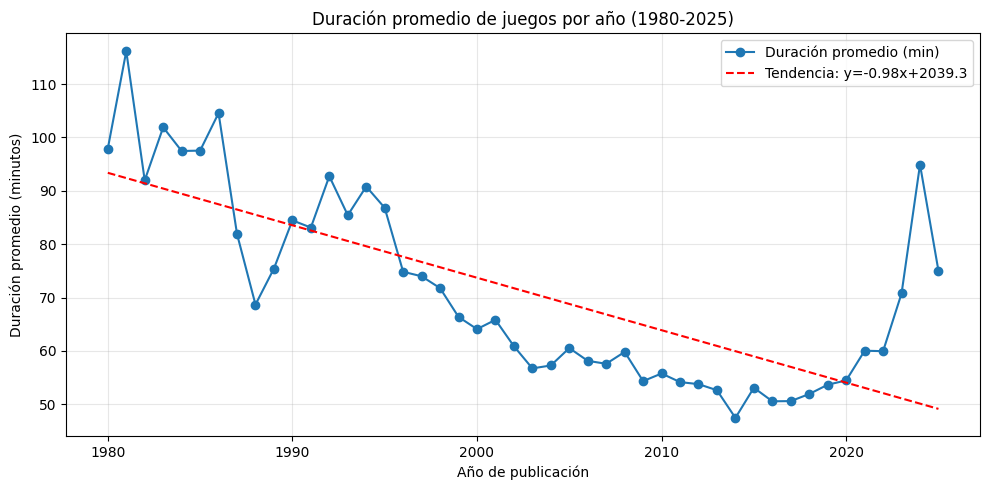

Pendiente estimada de la tendencia: -0.9828 min/año


In [63]:
# Graficar y estimar tendencia
print("[Paso 3] Graficando duración promedio anual (min) y estimando tendencia lineal...")

import matplotlib.pyplot as plt
import numpy as np

x = promedio_por_anio['YearPublished'].to_numpy()
y = promedio_por_anio['avg_time_min'].to_numpy()

plt.figure(figsize=(10,5))
plt.plot(x, y, marker='o', linewidth=1.5, label='Duración promedio (min)')

# Tendencia lineal
if len(x) >= 2:
    m, b = np.polyfit(x, y, 1)
    y_trend = m * x + b
    plt.plot(x, y_trend, color='red', linestyle='--', label=f'Tendencia: y={m:.2f}x+{b:.1f}')
    pendiente = m
else:
    pendiente = np.nan

plt.title('Duración promedio de juegos por año (1980-2025)')
plt.xlabel('Año de publicación')
plt.ylabel('Duración promedio (minutos)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pendiente estimada de la tendencia: {pendiente:.4f} min/año" if not np.isnan(pendiente) else "No se pudo estimar pendiente.")


**Comentario breve:**

- La serie muestra la duración promedio anual en minutos. La pendiente estimada resume la tendencia lineal: si es positiva, indica aumento gradual de la duración; si es negativa, sugiere reducción. Además, pueden existir fluctuaciones puntuales por lanzamientos atípicos o cambios en preferencias del mercado.
- Interprete la magnitud de la pendiente en contexto: por ejemplo, una pendiente de ~0.5–1.5 min/año implica un cambio suave pero sostenido en décadas.


**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

In [64]:
# Seleccionar dataset base con YearPublished, AvgWeight y NumVotes
print("Seleccionando dataset base con 'YearPublished', 'AvgWeight' y 'NumVotes'...")

import pandas as pd

# Intentamos usar un DataFrame ya en memoria
candidatos = []
for nombre in [
    'games_with_avg_time', 'df_33c', 'base', 'df_filtrado', 'resultado_33a'
]:
    if nombre in globals():
        df_tmp = globals()[nombre]
        if {'YearPublished','AvgWeight','NumVotes'}.issubset(df_tmp.columns):
            candidatos.append((nombre, df_tmp))

if candidatos:
    origen, df_33d = candidatos[0][0], candidatos[0][1].copy()
else:
    print("No se encontró dataset en memoria con columnas requeridas. Cargando CSV...")
    df_33d = pd.read_csv("data/juegos_unificados.csv")
    origen = 'CSV'

print(f"Fuente seleccionada: {origen} | forma: {df_33d.shape}")
print("Columnas disponibles (subset):", [c for c in ['YearPublished','AvgWeight','NumVotes'] if c in df_33d.columns])


Seleccionando dataset base con 'YearPublished', 'AvgWeight' y 'NumVotes'...
Fuente seleccionada: games_with_avg_time | forma: (43091, 52)
Columnas disponibles (subset): ['YearPublished', 'AvgWeight', 'NumVotes']


In [66]:
# Normalizar tipos y filtrar rango de años 1980-2025
print(" Normalizando tipos y filtrando años válidos (1980-2025)...")

for c in ["YearPublished","AvgWeight","NumVotes"]:
    if c in df_33d.columns:
        df_33d[c] = pd.to_numeric(df_33d[c], errors="coerce")

antes = len(df_33d)
df_33d = df_33d.dropna(subset=["YearPublished","AvgWeight","NumVotes"]).copy()
df_33d = df_33d.query("YearPublished >= 1980 and YearPublished <= 2025 and 1 <= AvgWeight <= 5 and NumVotes >= 100")
despues = len(df_33d)
print(f"Filas antes: {antes} | después de filtros: {despues} | removidas: {antes - despues}")
print("Estadísticas de AvgWeight tras filtros:")
print(df_33d["AvgWeight"].describe().round(2))


 Normalizando tipos y filtrando años válidos (1980-2025)...
Filas antes: 12703 | después de filtros: 12703 | removidas: 0
Estadísticas de AvgWeight tras filtros:
count    12703.00
mean         2.09
std          0.79
min          1.00
25%          1.42
50%          2.00
75%          2.60
max          4.82
Name: AvgWeight, dtype: float64


In [68]:
# Agregar complejidad promedio por año
print(" Calculando complejidad promedio (AvgWeight) por año...")

promedio_weight_por_anio = (
    df_33d.groupby('YearPublished', as_index=False)['AvgWeight']
          .mean()
          .rename(columns={'AvgWeight':'avg_weight'})
)
print("Filas agregadas:", len(promedio_weight_por_anio))
print(promedio_weight_por_anio.head())


 Calculando complejidad promedio (AvgWeight) por año...
Filas agregadas: 45
   YearPublished  avg_weight
0         1980.0    2.436279
1         1981.0    2.299837
2         1982.0    2.094748
3         1983.0    2.311533
4         1984.0    2.317510


 Graficando complejidad promedio por año y estimando tendencia...


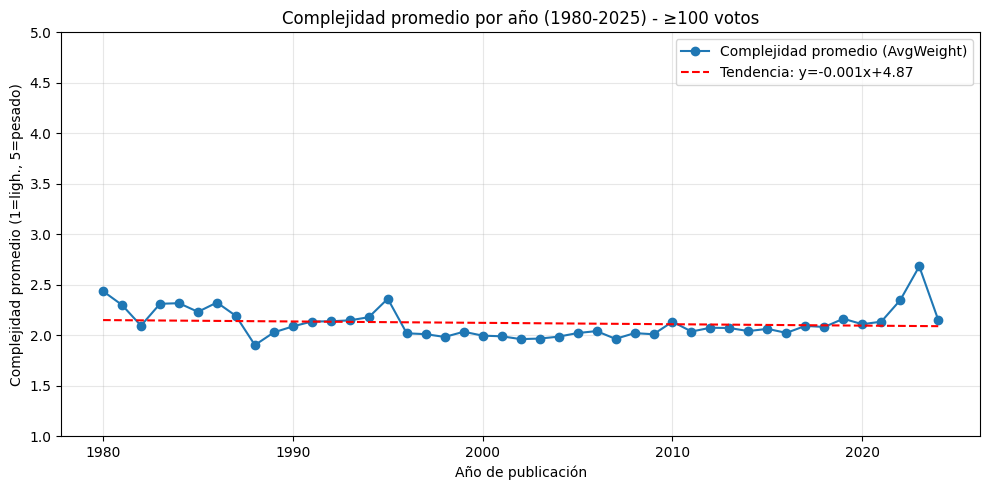

Pendiente estimada de la tendencia (AvgWeight): -0.0014 por año


In [69]:
# Graficar complejidad promedio por año con tendencia
print(" Graficando complejidad promedio por año y estimando tendencia...")

import matplotlib.pyplot as plt
import numpy as np

x = promedio_weight_por_anio['YearPublished'].to_numpy()
y = promedio_weight_por_anio['avg_weight'].to_numpy()

plt.figure(figsize=(10,5))
plt.plot(x, y, marker='o', linewidth=1.5, color='#1f77b4', label='Complejidad promedio (AvgWeight)')

# Tendencia lineal
if len(x) >= 2:
    m, b = np.polyfit(x, y, 1)
    y_trend = m * x + b
    plt.plot(x, y_trend, color='red', linestyle='--', label=f'Tendencia: y={m:.3f}x+{b:.2f}')
    pendiente_weight = m
else:
    pendiente_weight = np.nan

plt.title('Complejidad promedio por año (1980-2025) - ≥100 votos')
plt.xlabel('Año de publicación')
plt.ylabel('Complejidad promedio (1=ligh., 5=pesado)')
plt.ylim(1, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pendiente estimada de la tendencia (AvgWeight): {pendiente_weight:.4f} por año" if not np.isnan(pendiente_weight) else "No se pudo estimar pendiente.")


**Comentario 3.3d:**

- Con el filtro de ≥100 votos reducimos sesgo de estimaciones inestables. La pendiente de la línea de tendencia indica el cambio promedio anual en complejidad: positiva sugiere que los juegos recientes son más complejos; negativa sugiere lo contrario.
- Compare visualmente el nivel antes y después de 2000; además, interprete la magnitud de la pendiente (por ejemplo, +0.01 a +0.03 por año implica un aumento leve pero sostenido en décadas).


### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

Cargando DataFrame unificado...
DataFrame cargado con 93019 juegos entre 1980-2025
Top 5 categorías más comunes:
1. Card Game: 25900 juegos
2. Wargame: 12502 juegos
3. Children's Game: 11706 juegos
4. Party Game: 9574 juegos
5. Fantasy: 8358 juegos

DataFrame de las top 5 categorías:
         Categoría  Cantidad
0        Card Game     25900
1          Wargame     12502
2  Children's Game     11706
3       Party Game      9574
4          Fantasy      8358


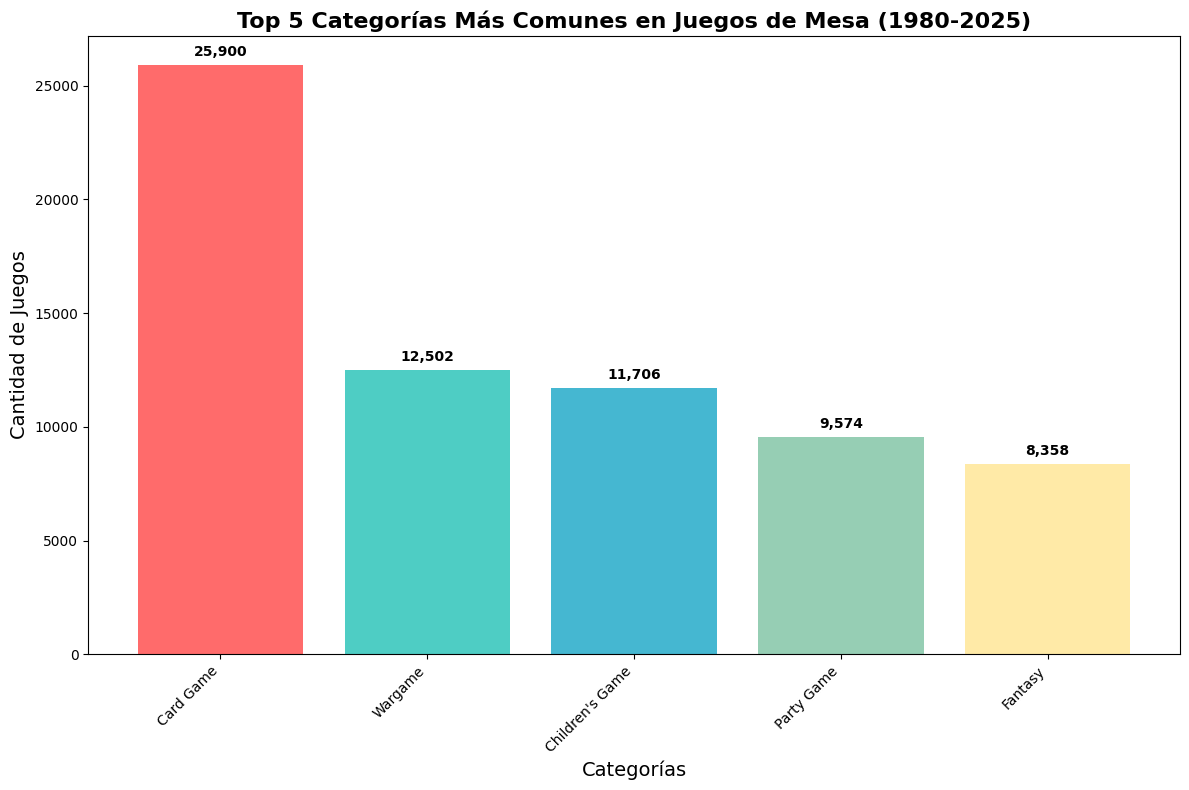

In [91]:
# Cargar el DataFrame unificado
print("Cargando DataFrame unificado...")
games = pd.read_csv('./data/juegos_unificados.csv')

# Filtrar solo juegos entre 1980-2025 con año válido
games_1980_2025 = games[
    (games['YearPublished'] >= 1980) & 
    (games['YearPublished'] <= 2025) &
    (games['YearPublished'].notna())
].copy()

print(f"DataFrame cargado con {len(games_1980_2025)} juegos entre 1980-2025")

# 3.4a) Encontrar las 5 categorías más comunes

# Función para contar categorías
def contar_categorias(df, columna_categoria):
    """Cuenta la frecuencia de cada categoría"""
    categorias = []
    for categorias_str in df[columna_categoria].dropna():
        if pd.notna(categorias_str) and categorias_str != 'nan':
            # Dividir por punto y coma y agregar cada categoría
            cats = str(categorias_str).split('; ')
            categorias.extend(cats)
    
    # Contar frecuencias
    from collections import Counter
    contador = Counter(categorias)
    return contador

# Contar categorías
contador_categorias = contar_categorias(games_1980_2025, 'CategoryName')

# Obtener las 5 más comunes
top_5_categorias = contador_categorias.most_common(5)

print("Top 5 categorías más comunes:")
for i, (categoria, cantidad) in enumerate(top_5_categorias, 1):
    print(f"{i}. {categoria}: {cantidad} juegos")

# Crear DataFrame con las top 5
df_top_5 = pd.DataFrame(top_5_categorias, columns=['Categoría', 'Cantidad'])
print("\nDataFrame de las top 5 categorías:")
print(df_top_5)

# Graficar las top 5 categorías
plt.figure(figsize=(12, 8))
categorias = [cat[0] for cat in top_5_categorias]
cantidades = [cat[1] for cat in top_5_categorias]

bars = plt.bar(range(len(categorias)), cantidades, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Top 5 Categorías Más Comunes en Juegos de Mesa (1980-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Categorías', fontsize=14)
plt.ylabel('Cantidad de Juegos', fontsize=14)
plt.xticks(range(len(categorias)), categorias, rotation=45, ha='right')

# Agregar valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01*max(cantidades),
             f'{cantidades[i]:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('./data/top_5_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

In [92]:
def contar_categorias_por_anio(df, categoria_objetivo):
    """Cuenta cuántos juegos de una categoría específica hay por año"""
    conteo_por_anio = {}
    
    for _, row in df.iterrows():
        anio = row['YearPublished']
        categorias = str(row['CategoryName']).split('; ') if pd.notna(row['CategoryName']) else []
        
        if categoria_objetivo in categorias:
            if anio in conteo_por_anio:
                conteo_por_anio[anio] += 1
            else:
                conteo_por_anio[anio] = 1
    
    return conteo_por_anio

# Crear DataFrames para cada categoría top 5
dfs_categorias = []

for categoria, _ in top_5_categorias:
    conteo = contar_categorias_por_anio(games_1980_2025, categoria)
    
    if conteo:  # Solo si hay datos
        df_temp = pd.DataFrame(list(conteo.items()), columns=['Año', 'Cantidad'])
        df_temp['Categoría'] = categoria
        dfs_categorias.append(df_temp)

# Unir todos los DataFrames
df_final = pd.concat(dfs_categorias, ignore_index=True)

print("DataFrame con cantidad por año por categoría creado:")
print(f"Filas: {len(df_final)}")
print(f"Columnas: {list(df_final.columns)}")
print("\nPrimeras filas:")
print(df_final.head(10))

# Guardar el DataFrame
df_final.to_csv('./data/categorias_por_anio.csv', index=False)
print("\nDataFrame guardado como 'categorias_por_anio.csv'")

DataFrame con cantidad por año por categoría creado:
Filas: 228
Columnas: ['Año', 'Cantidad', 'Categoría']

Primeras filas:
      Año  Cantidad  Categoría
0  1981.0        52  Card Game
1  1997.0       159  Card Game
2  1987.0        78  Card Game
3  1998.0       225  Card Game
4  1999.0       228  Card Game
5  1996.0       187  Card Game
6  1995.0       183  Card Game
7  1992.0       112  Card Game
8  1993.0       103  Card Game
9  1982.0        58  Card Game

DataFrame guardado como 'categorias_por_anio.csv'


**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


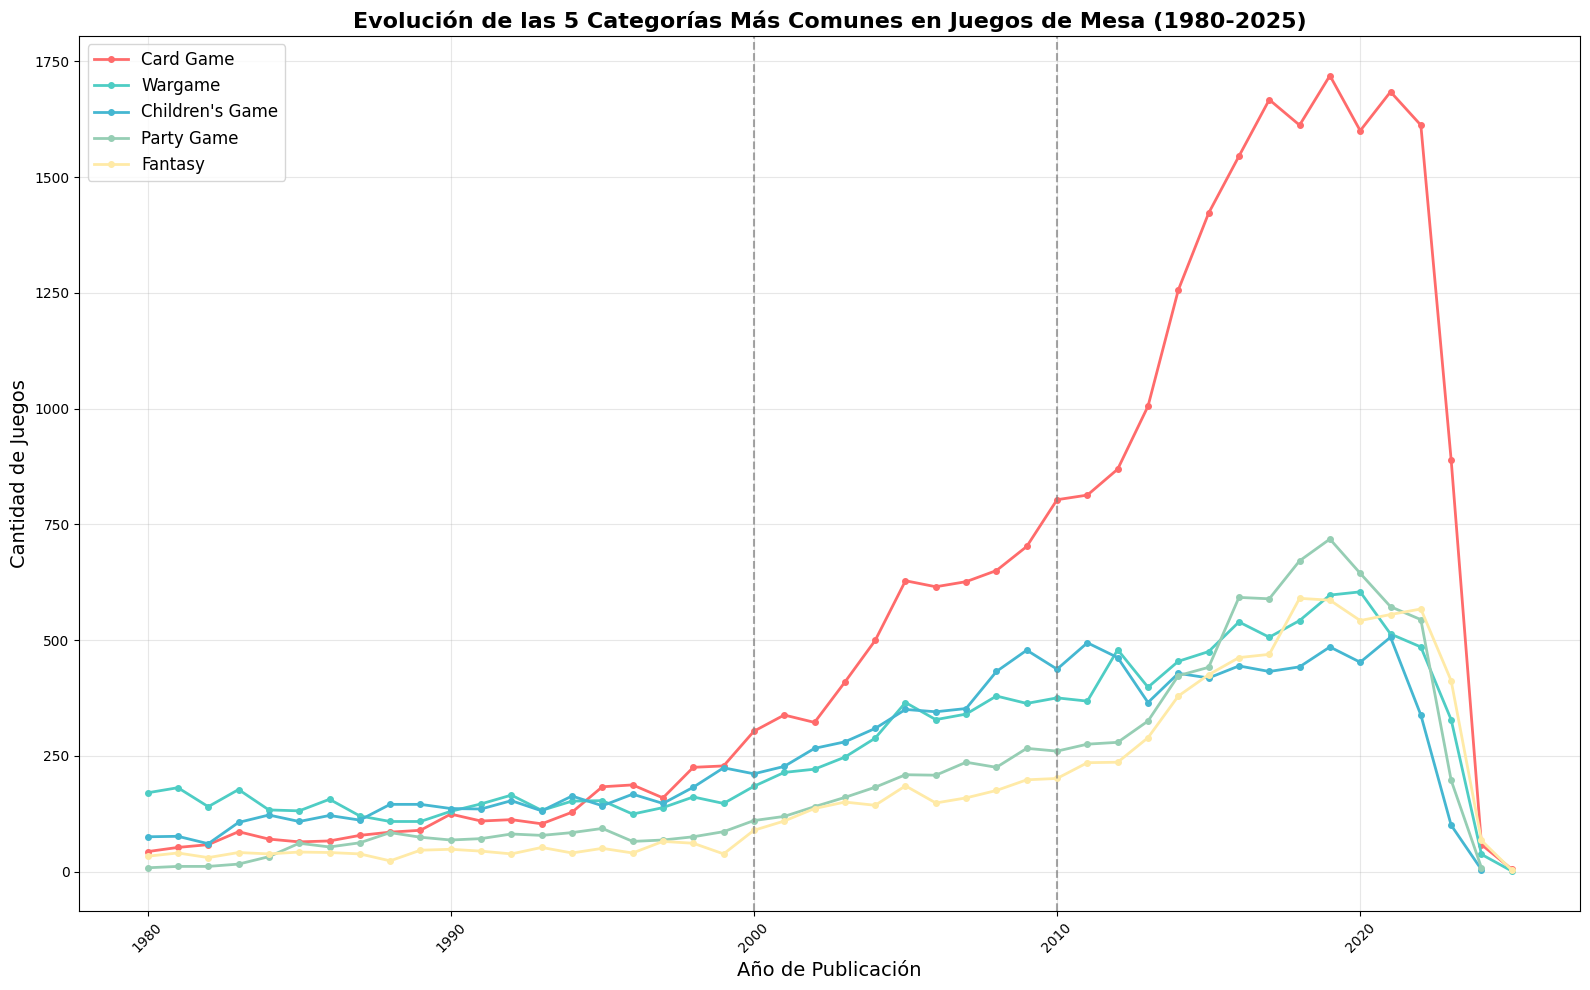


=== ANÁLISIS DE CAMBIOS ENTRE LOS 80 Y HOY ===
Comparación entre décadas:
Década de 1980:
  Card Game: 691 juegos
  Wargame: 1424 juegos
  Children's Game: 1069 juegos
  Party Game: 412 juegos
  Fantasy: 372 juegos

Década actual (2015-2025):
  Card Game: 13813 juegos
  Wargame: 4627 juegos
  Children's Game: 3621 juegos
  Party Game: 4976 juegos
  Fantasy: 4678 juegos

Cambios porcentuales (década actual vs década de 1980):
  Card Game: +1899.0%
  Wargame: +224.9%
  Children's Game: +238.7%
  Party Game: +1107.8%
  Fantasy: +1157.5%


In [93]:
# Graficar todas las categorías en un solo gráfico

# Crear gráfico con todas las categorías
plt.figure(figsize=(16, 10))

# Colores para cada categoría
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for i, (categoria, _) in enumerate(top_5_categorias):
    # Filtrar datos para esta categoría
    datos_categoria = df_final[df_final['Categoría'] == categoria].sort_values('Año')
    
    if len(datos_categoria) > 0:
        plt.plot(datos_categoria['Año'], datos_categoria['Cantidad'], 
                marker='o', linewidth=2, markersize=4, 
                color=colores[i], label=categoria)

plt.title('Evolución de las 5 Categorías Más Comunes en Juegos de Mesa (1980-2025)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Año de Publicación', fontsize=14)
plt.ylabel('Cantidad de Juegos', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)

# Agregar anotaciones para años importantes
plt.axvline(x=2000, color='gray', linestyle='--', alpha=0.7, label='Año 2000')
plt.axvline(x=2010, color='gray', linestyle='--', alpha=0.7, label='Año 2010')

plt.tight_layout()
plt.savefig('./data/evolucion_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis de los cambios
print("\n=== ANÁLISIS DE CAMBIOS ENTRE LOS 80 Y HOY ===")

# Comparar décadas
decada_80 = df_final[df_final['Año'].between(1980, 1989)]
decada_actual = df_final[df_final['Año'].between(2015, 2025)]

print("Comparación entre décadas:")
print("Década de 1980:")
for categoria, _ in top_5_categorias:
    total_80 = decada_80[decada_80['Categoría'] == categoria]['Cantidad'].sum()
    print(f"  {categoria}: {total_80} juegos")

print("\nDécada actual (2015-2025):")
for categoria, _ in top_5_categorias:
    total_actual = decada_actual[decada_actual['Categoría'] == categoria]['Cantidad'].sum()
    print(f"  {categoria}: {total_actual} juegos")

# Calcular cambios porcentuales
print("\nCambios porcentuales (década actual vs década de 1980):")
for categoria, _ in top_5_categorias:
    total_80 = decada_80[decada_80['Categoría'] == categoria]['Cantidad'].sum()
    total_actual = decada_actual[decada_actual['Categoría'] == categoria]['Cantidad'].sum()
    
    if total_80 > 0:
        cambio_porcentual = ((total_actual - total_80) / total_80) * 100
        print(f"  {categoria}: {cambio_porcentual:+.1f}%")
    else:
        print(f"  {categoria}: No disponible en 1980s")

### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?